In [1]:
import geopandas as gpd
from shapely.geometry import Polygon
import folium

In [2]:
default_bbox = [[10.045725448115505, 53.56373965563346],
               [10.04483158296414, 53.56928571310496],
               [10.061462179332965, 53.574146646448916],
               [10.064284911389908, 53.56640800076195]]
def_poly = Polygon(default_bbox)
def_poly_gdf = gpd.GeoDataFrame(geometry=[def_poly], crs="EPSG:4326")

In [3]:
m = folium.Map(location=[53.56, 10.06], zoom_start=14, tiles="CartoDB positron")
for _, row in def_poly_gdf.iterrows():
        folium.GeoJson(row["geometry"], style_function=lambda x: {"fillColor": "orange"}).add_to(m)
m

In [4]:
buildings_gdf = gpd.read_parquet("buildings.parquet")
buildings_gdf = buildings_gdf.to_crs("EPSG:4326")

In [6]:
poly_geom = def_poly_gdf.geometry.iloc[0]

filtered_buildings_gdf = buildings_gdf[buildings_gdf.geometry.intersects(poly_geom)].copy()
#filtered_buildings_gdf = filtered_buildings_gdf.reset_index(drop=True)

print(filtered_buildings_gdf.shape)
#print(filtered_buildings_gdf.head())

(829, 25)


In [7]:
m = folium.Map(location=[53.56, 10.06], zoom_start=14, tiles="CartoDB positron")
for _, row in filtered_buildings_gdf.iterrows():
        folium.GeoJson(row["geometry"], style_function=lambda x: {"fillColor": "orange"}).add_to(m)
m

<Axes: >

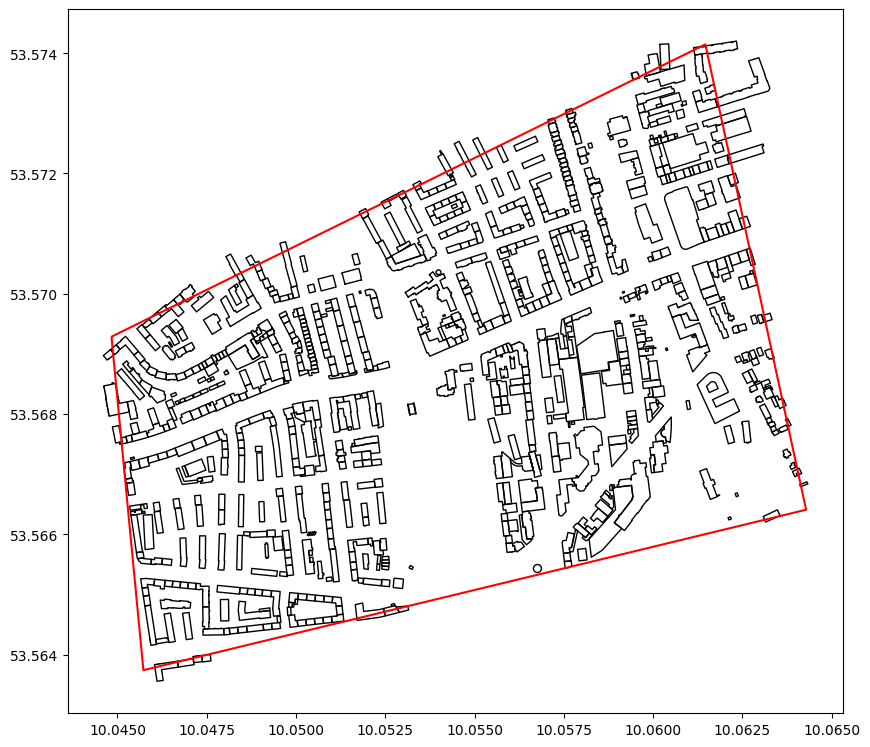

In [8]:
ax = filtered_buildings_gdf.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
def_poly_gdf.boundary.plot(ax=ax, color="red")